In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('./data/titanic_clean.csv')

In [3]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
778,0,3,male,28.0,0,0,7.7375,Q
785,0,3,male,25.0,0,0,7.2500,S
351,0,1,male,28.0,0,0,35.0000,S
28,1,3,female,28.0,0,0,7.8792,Q


In [4]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [5]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

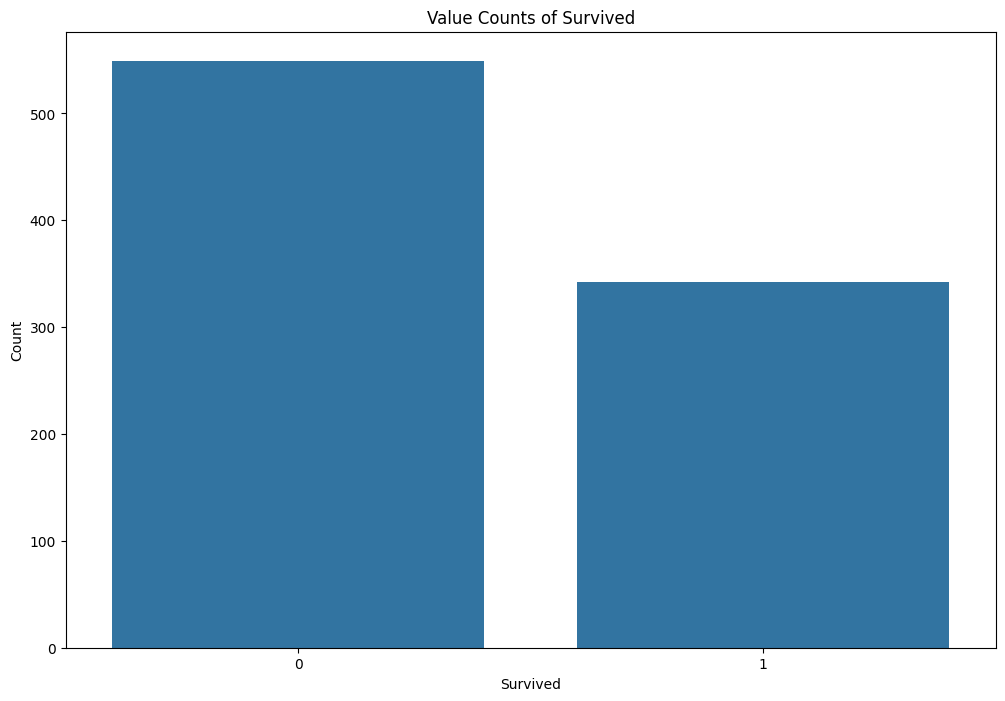

In [6]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

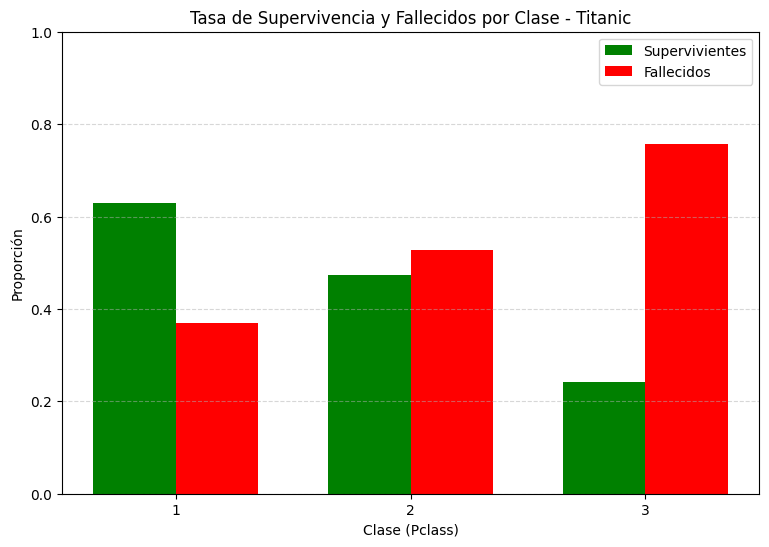

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar dataset
df = pd.read_csv('./data/titanic_clean.csv')

# Ordenar clases
clases = np.sort(df['Pclass'].unique())

# Listas para almacenar tasas
tasas_supervivientes = []
tasas_fallecidos = []

for clase in clases:
    datos_clase = df[df['Pclass'] == clase]['Survived'].values
    
    tasa_superv = np.mean(datos_clase)          # proporción de 1
    tasa_fall = 1 - tasa_superv                # proporción de 0
    
    tasas_supervivientes.append(tasa_superv)
    tasas_fallecidos.append(tasa_fall)

tasas_supervivientes = np.array(tasas_supervivientes)
tasas_fallecidos = np.array(tasas_fallecidos)

# Configuración de barras
x = np.arange(len(clases))
ancho = 0.35

plt.figure(figsize=(9,6))

plt.bar(x - ancho/2, tasas_supervivientes, 
        width=ancho, label='Supervivientes', color='green')

plt.bar(x + ancho/2, tasas_fallecidos, 
        width=ancho, label='Fallecidos', color='red')

plt.xlabel('Clase (Pclass)')
plt.ylabel('Proporción')
plt.title('Tasa de Supervivencia y Fallecidos por Clase - Titanic')
plt.xticks(x, clases)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

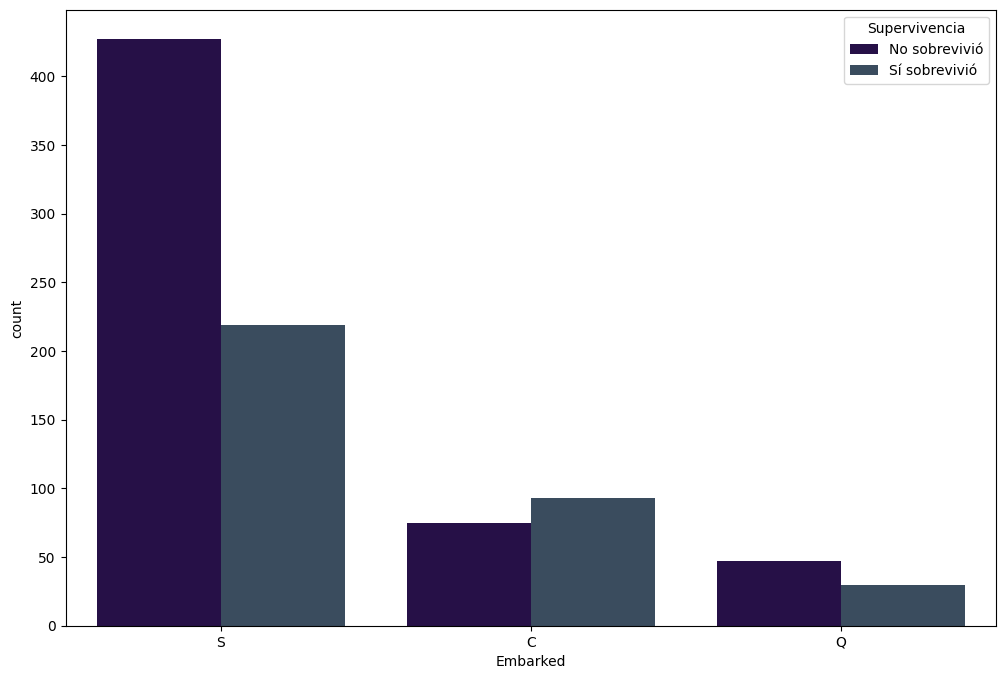

In [12]:
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

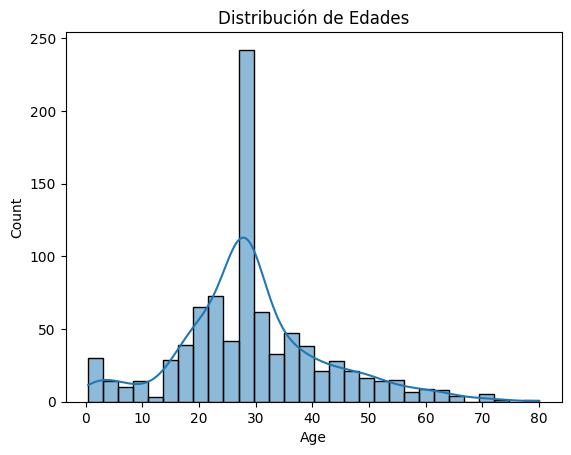

In [12]:
plt.figure()
sns.histplot(df["Age"].dropna(), bins=30, kde=True)
plt.title("Distribución de Edades")
plt.show()

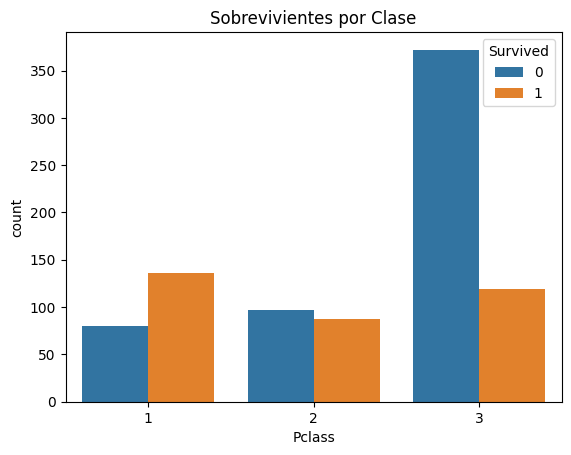

In [13]:
plt.figure()
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Sobrevivientes por Clase")
plt.show()

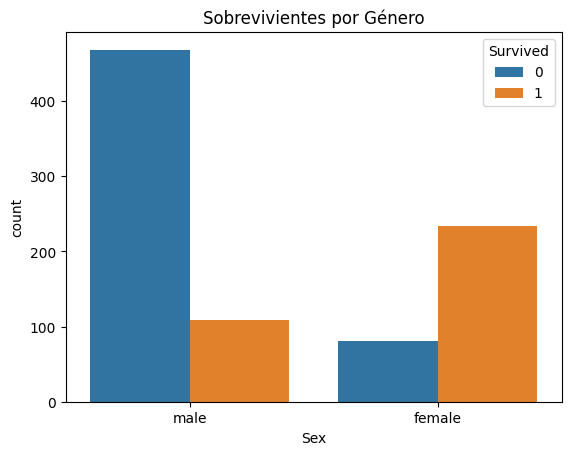

In [14]:
plt.figure()
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Sobrevivientes por Género")
plt.show()

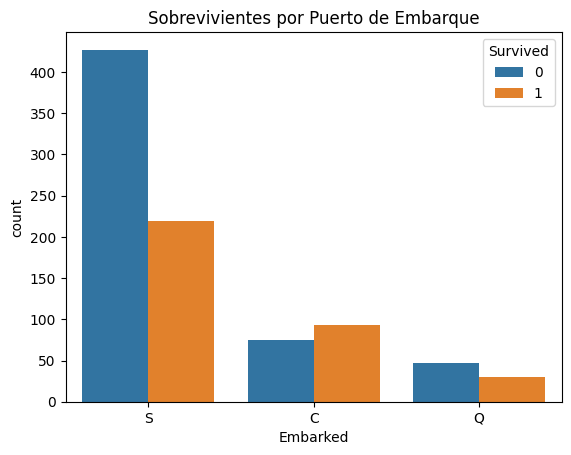

In [15]:
plt.figure()
sns.countplot(data=df, x="Embarked", hue="Survived")
plt.title("Sobrevivientes por Puerto de Embarque")
plt.show()


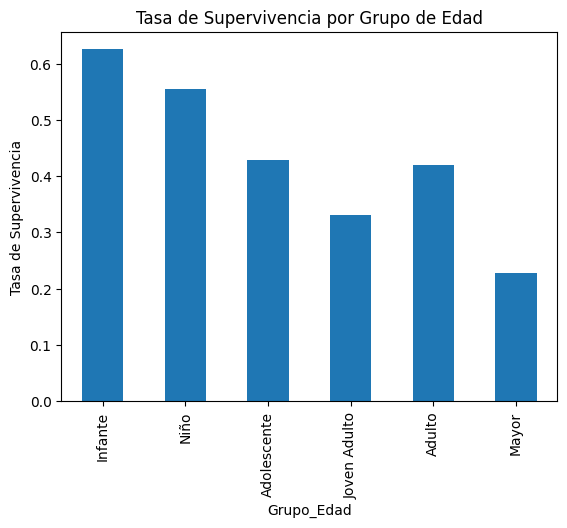

In [16]:
bins = [0, 2, 12, 18, 30, 60, 100]
labels = ["Infante", "Niño", "Adolescente", "Joven Adulto", "Adulto", "Mayor"]

df["Grupo_Edad"] = pd.cut(df["Age"], bins=bins, labels=labels)

survival_age = df.groupby("Grupo_Edad")["Survived"].mean()

plt.figure()
survival_age.plot(kind="bar")
plt.title("Tasa de Supervivencia por Grupo de Edad")
plt.ylabel("Tasa de Supervivencia")
plt.show()


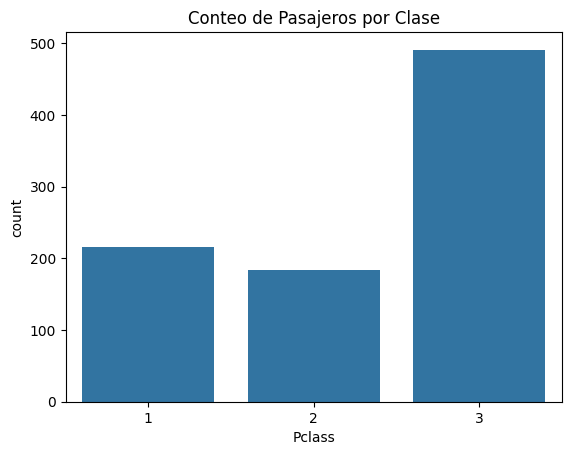

In [17]:
plt.figure()
sns.countplot(data=df, x="Pclass")
plt.title("Conteo de Pasajeros por Clase")
plt.show()

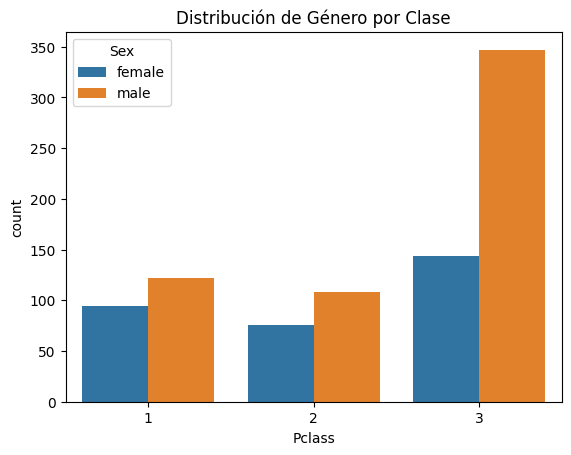

In [18]:
plt.figure()
sns.countplot(data=df, x="Pclass", hue="Sex")
plt.title("Distribución de Género por Clase")
plt.show()


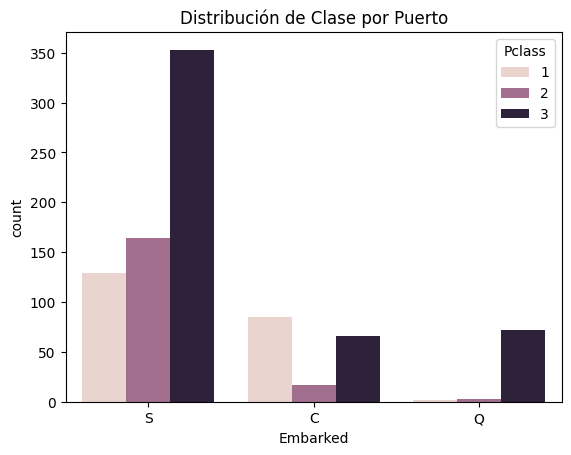

In [19]:
plt.figure()
sns.countplot(data=df, x="Embarked", hue="Pclass")
plt.title("Distribución de Clase por Puerto")
plt.show()


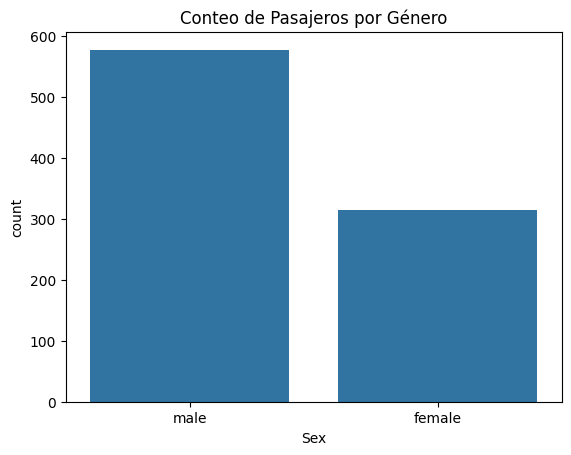

In [20]:
plt.figure()
sns.countplot(data=df, x="Sex")
plt.title("Conteo de Pasajeros por Género")
plt.show()

In [21]:
print("Edad máxima:", df["Age"].max())
print("Edad mínima:", df["Age"].min())


Edad máxima: 80.0
Edad mínima: 0.42


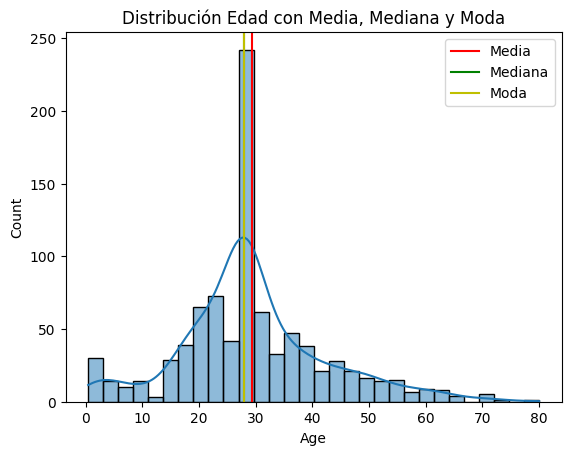

In [23]:
mean_age = df["Age"].mean()
median_age = df["Age"].median()
mode_age = df["Age"].mode()[0]

plt.figure()
sns.histplot(df["Age"].dropna(), bins=30, kde=True)
plt.axvline(mean_age, color='r', label='Media')
plt.axvline(median_age, color='g', label='Mediana')
plt.axvline(mode_age, color='y', label='Moda')
plt.legend()
plt.title("Distribución Edad con Media, Mediana y Moda")
plt.show()


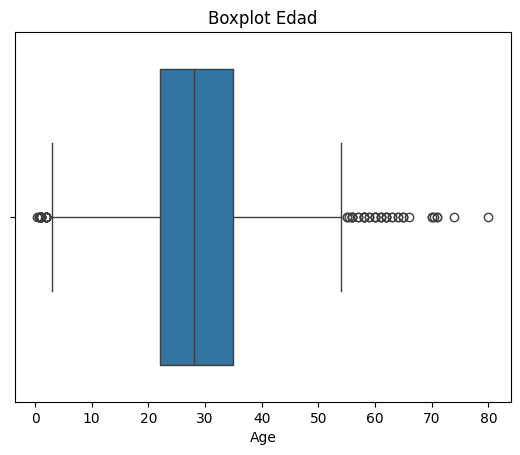

In [24]:
plt.figure()
sns.boxplot(x=df["Age"])
plt.title("Boxplot Edad")
plt.show()


In [25]:
print("Tarifa máxima:", df["Fare"].max())
print("Tarifa mínima:", df["Fare"].min())

Tarifa máxima: 512.3292
Tarifa mínima: 0.0


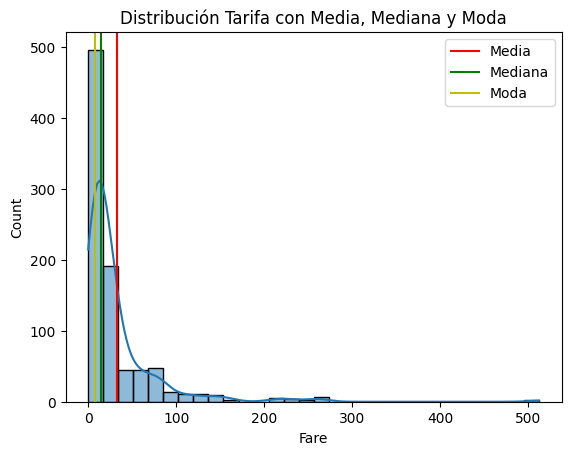

In [26]:
mean_fare = df["Fare"].mean()
median_fare = df["Fare"].median()
mode_fare = df["Fare"].mode()[0]

plt.figure()
sns.histplot(df["Fare"], bins=30, kde=True)
plt.axvline(mean_fare, color='r', label='Media')
plt.axvline(median_fare, color='g', label='Mediana')
plt.axvline(mode_fare, color='y', label='Moda')
plt.legend()
plt.title("Distribución Tarifa con Media, Mediana y Moda")
plt.show()

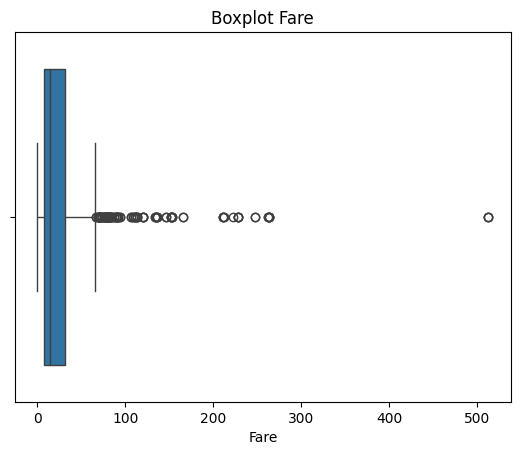

In [27]:
plt.figure()
sns.boxplot(x=df["Fare"])
plt.title("Boxplot Fare")
plt.show()


In [28]:
fare_zero = df[df["Fare"] == 0]
print("Pasajeros con tarifa 0:")
print(fare_zero)

Pasajeros con tarifa 0:
     Survived  Pclass   Sex   Age  SibSp  Parch  Fare Embarked    Grupo_Edad
179         0       3  male  36.0      0      0   0.0        S        Adulto
263         0       1  male  40.0      0      0   0.0        S        Adulto
271         1       3  male  25.0      0      0   0.0        S  Joven Adulto
277         0       2  male  28.0      0      0   0.0        S  Joven Adulto
302         0       3  male  19.0      0      0   0.0        S  Joven Adulto
413         0       2  male  28.0      0      0   0.0        S  Joven Adulto
466         0       2  male  28.0      0      0   0.0        S  Joven Adulto
481         0       2  male  28.0      0      0   0.0        S  Joven Adulto
597         0       3  male  49.0      0      0   0.0        S        Adulto
633         0       1  male  28.0      0      0   0.0        S  Joven Adulto
674         0       2  male  28.0      0      0   0.0        S  Joven Adulto
732         0       2  male  28.0      0      0   0.

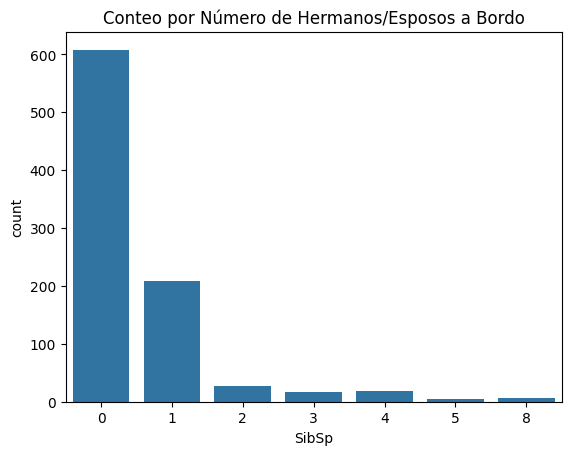

In [29]:
plt.figure()
sns.countplot(data=df, x="SibSp")
plt.title("Conteo por Número de Hermanos/Esposos a Bordo")
plt.show()

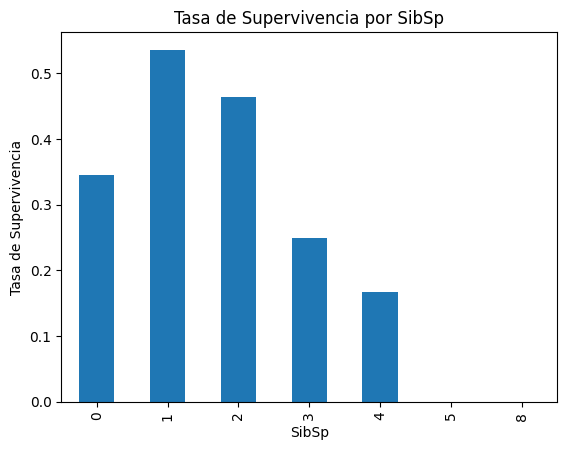

In [30]:
survival_sibsp = df.groupby("SibSp")["Survived"].mean()

plt.figure()
survival_sibsp.plot(kind="bar")
plt.title("Tasa de Supervivencia por SibSp")
plt.ylabel("Tasa de Supervivencia")
plt.show()

In [31]:
survival_percentage = survival_sibsp * 100
print("Porcentaje de Supervivencia por SibSp:")
print(survival_percentage)


Porcentaje de Supervivencia por SibSp:
SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64


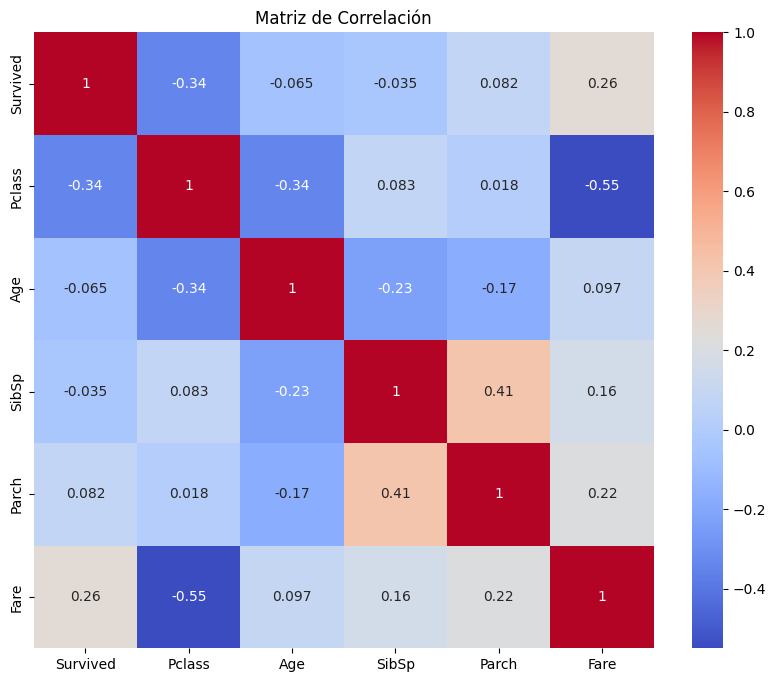

In [32]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()